In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [2]:
data = pd.read_csv("/content/drive/MyDrive/ML_Datasets/archive (23).zip")

In [3]:
data.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [5]:
data.shape

(1000, 16)

In [6]:
data.isna().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


In [7]:
data = data.dropna()
data

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000
mean,20.475248,3.538724,2.504620,1.830363,83.880308,6.474037,3.051705,5.466447,69.558196
std,2.302721,1.469730,1.164802,1.071251,9.453622,1.218943,2.035632,2.857525,16.929436
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.000000,2.500000,1.700000,1.000000,77.500000,5.600000,1.000000,3.000000,58.400000
50%,20.000000,3.500000,2.500000,1.800000,84.200000,6.500000,3.000000,5.000000,70.400000
75%,22.000000,4.500000,3.300000,2.600000,90.700000,7.300000,5.000000,8.000000,81.300000
max,24.000000,8.300000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [10]:
data.describe(include = "object")

,student_id,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,909,909,909,909,909,909,909
unique,909,3,2,3,3,3,2
top,S1999,Male,No,Fair,High School,Good,No
freq,1,440,713,396,392,410,620


In [11]:
categorical_columns = ["gender","part_time_job","diet_quality","parental_education_level","internet_quality","extracurricular_participation"]

In [12]:
for col in categorical_columns:
  print(f"Value counts for {col}: \n {data[col].value_counts()}")

Value counts for gender: 
 gender
Male      440
Female    433
Other      36
Name: count, dtype: int64
Value counts for part_time_job: 
 part_time_job
No     713
Yes    196
Name: count, dtype: int64
Value counts for diet_quality: 
 diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64
Value counts for parental_education_level: 
 parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
Value counts for internet_quality: 
 internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64
Value counts for extracurricular_participation: 
 extracurricular_participation
No     620
Yes    289
Name: count, dtype: int64


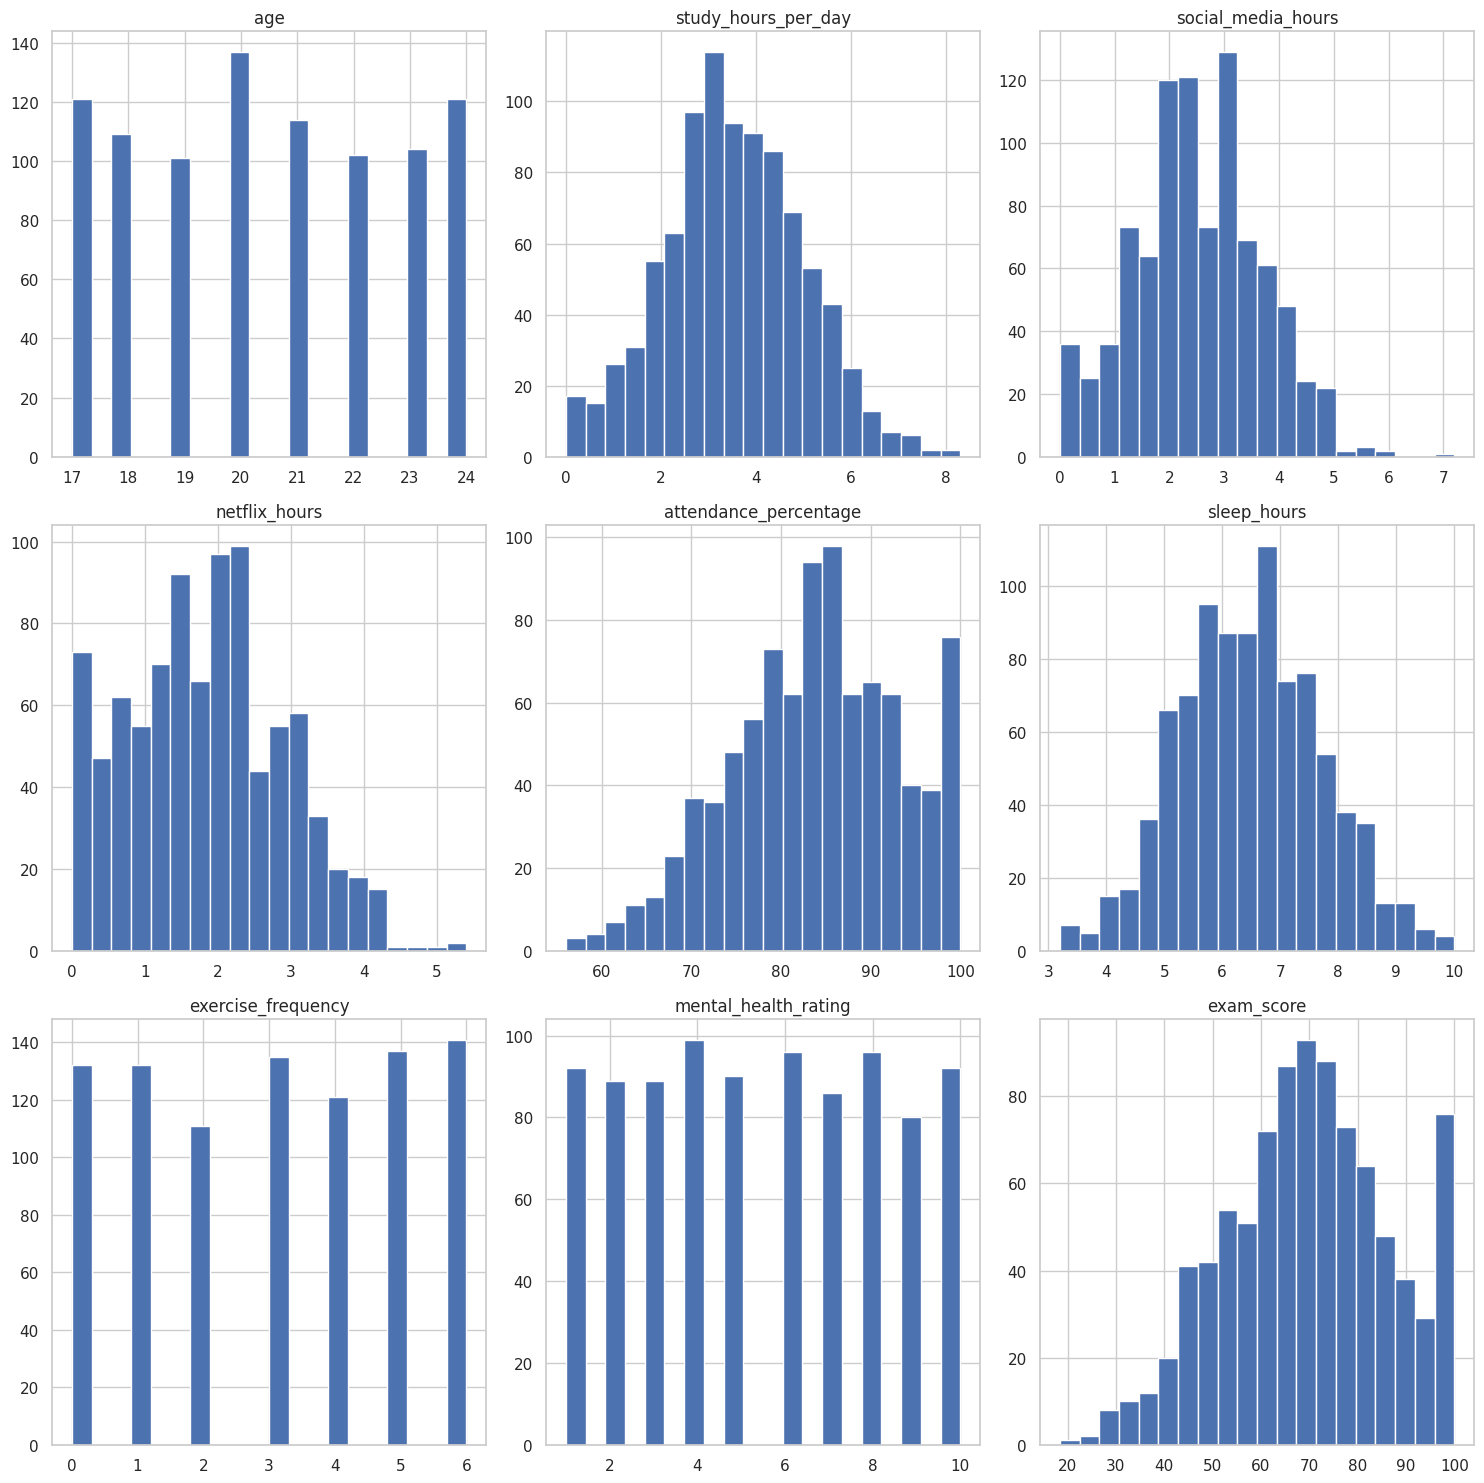

In [16]:
sns.set(style = "whitegrid")
data.hist(figsize = (15,15), bins = 20)
plt.tight_layout()
plt.show()

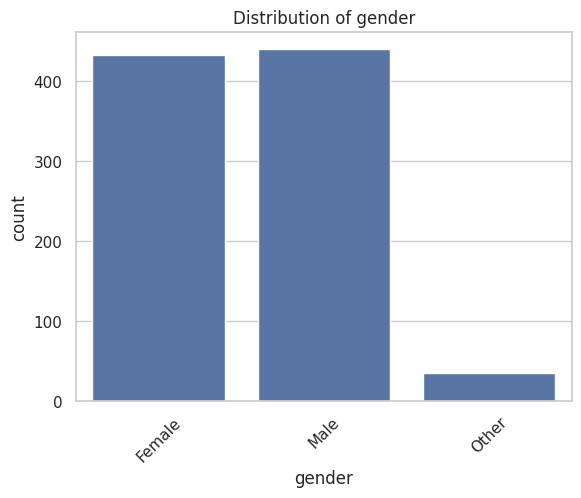

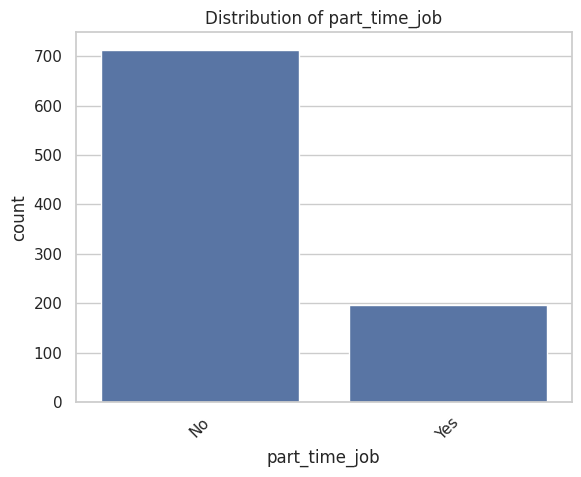

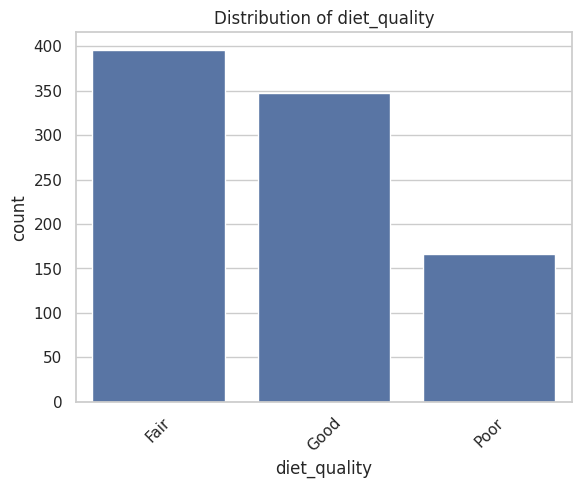

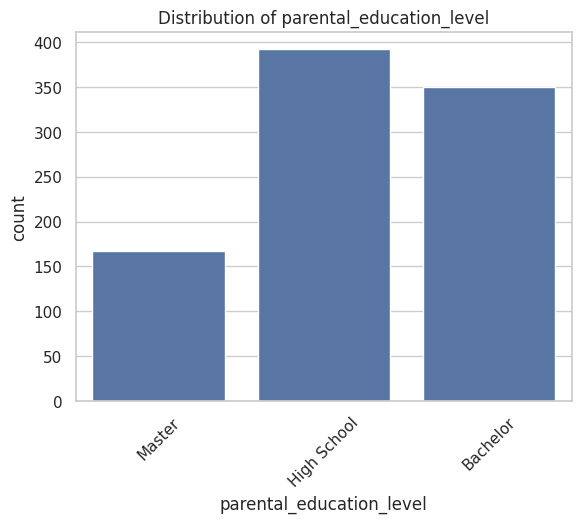

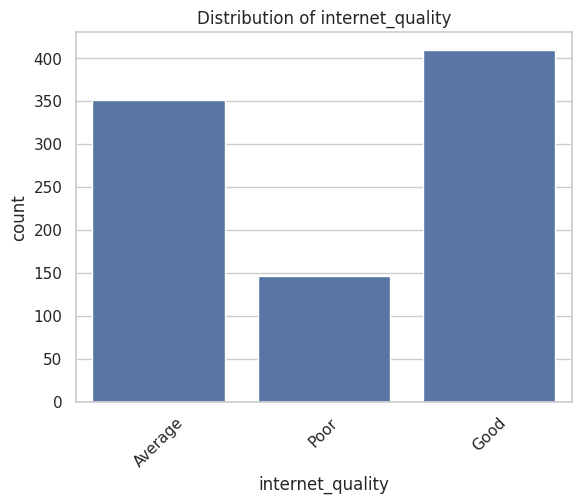

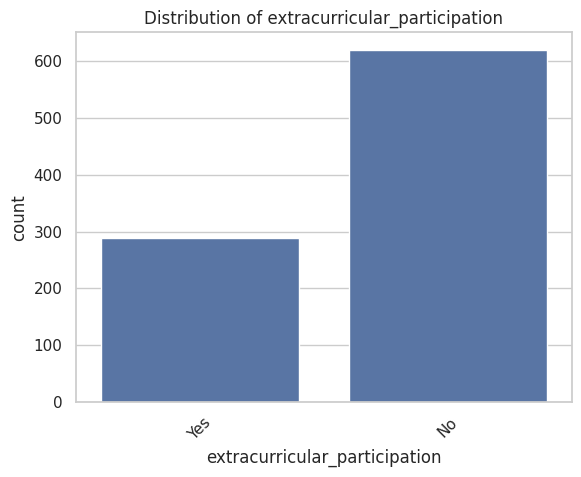

In [17]:
for col in categorical_columns:
    sns.countplot(data = data,x = col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation = 45)
    plt.show()

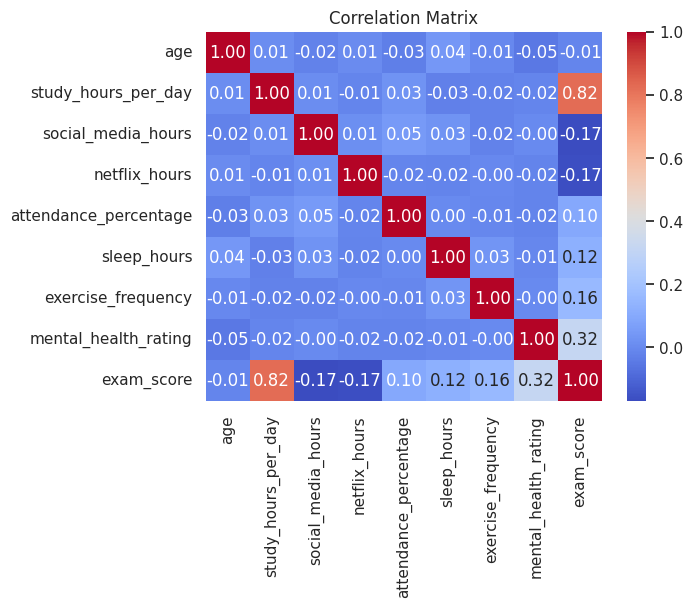

In [18]:
sns.heatmap(data.corr(numeric_only = True), annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Matrix")
plt.show()

In [19]:
data.describe().columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

In [22]:
num_features = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating']

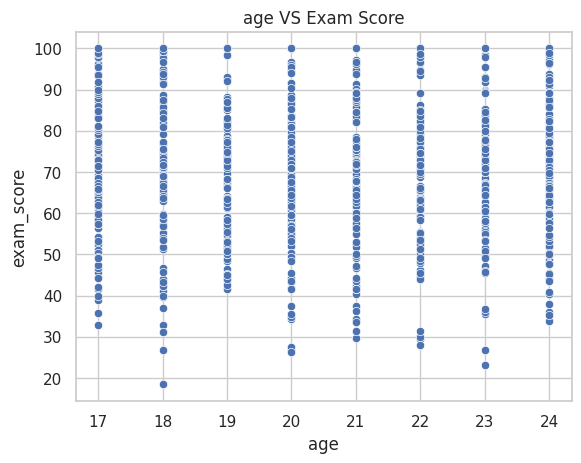

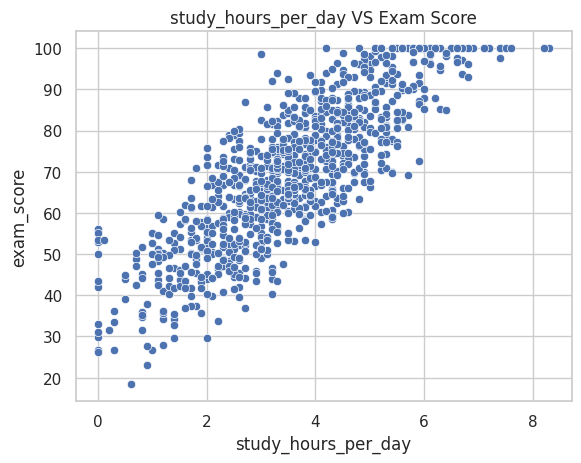

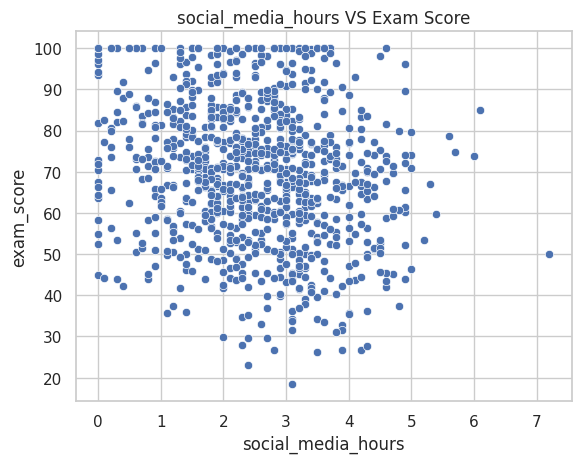

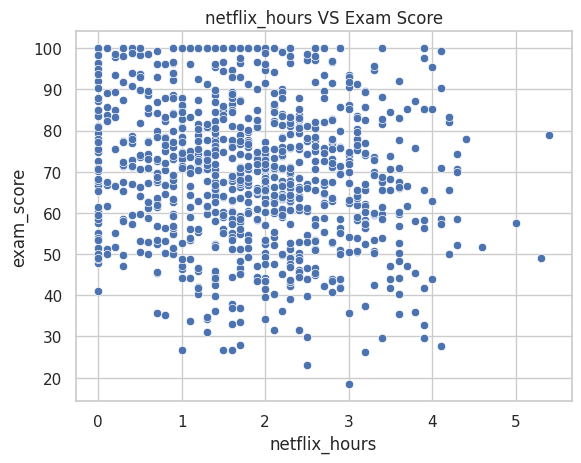

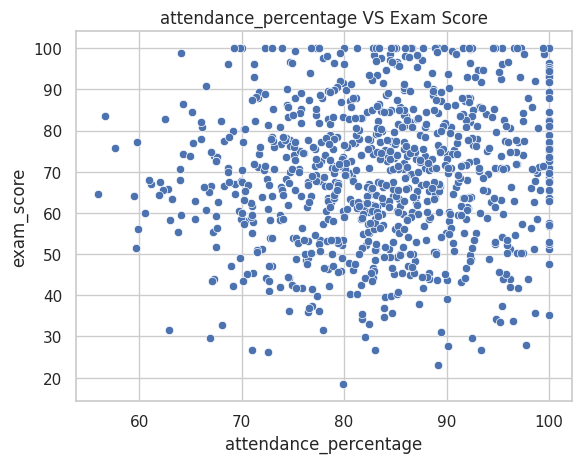

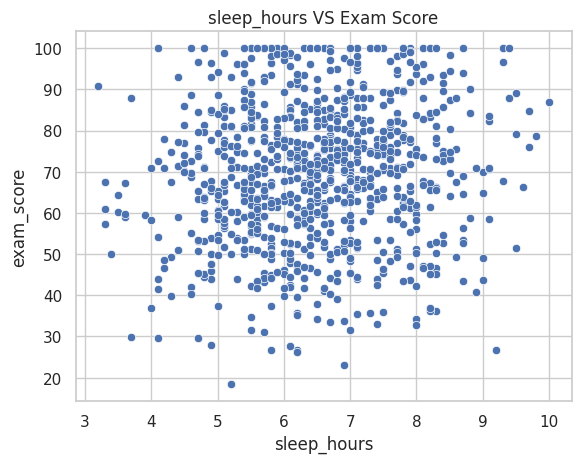

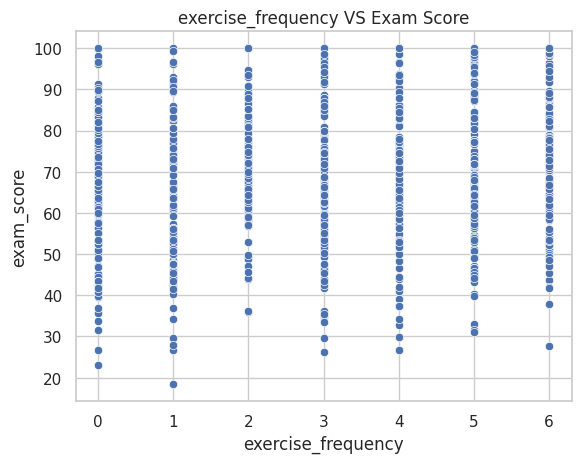

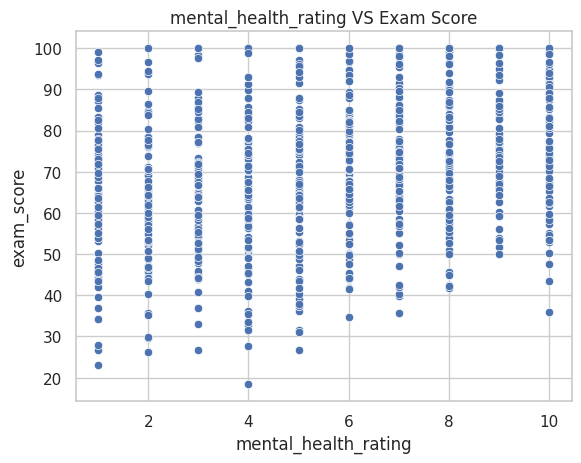

In [23]:
for feature in num_features:
    sns.scatterplot(data = data, x = feature, y = "exam_score")
    plt.title(f"{feature} VS Exam Score")
    plt.show()

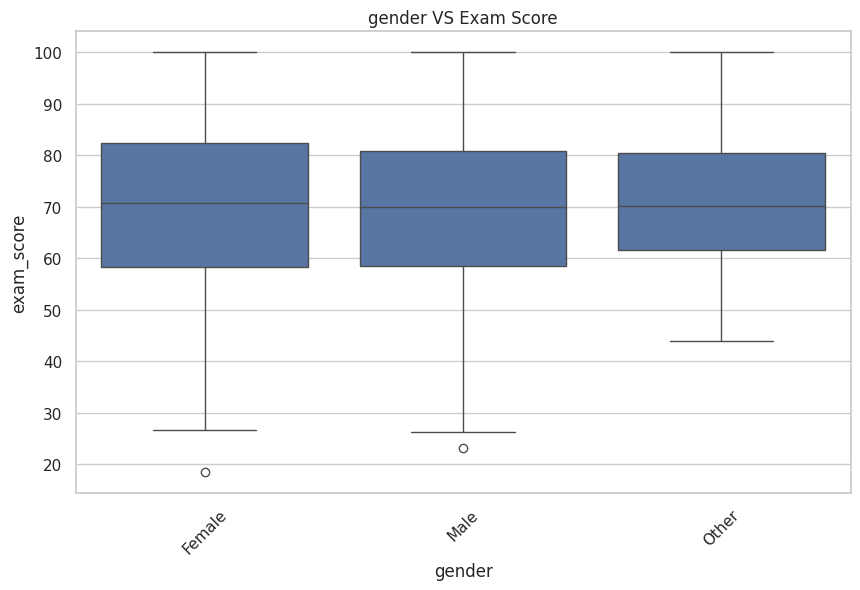

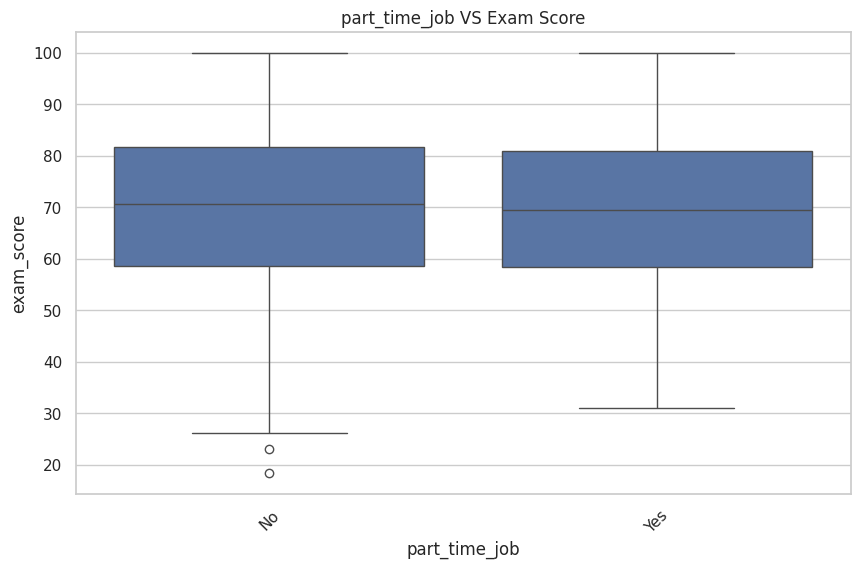

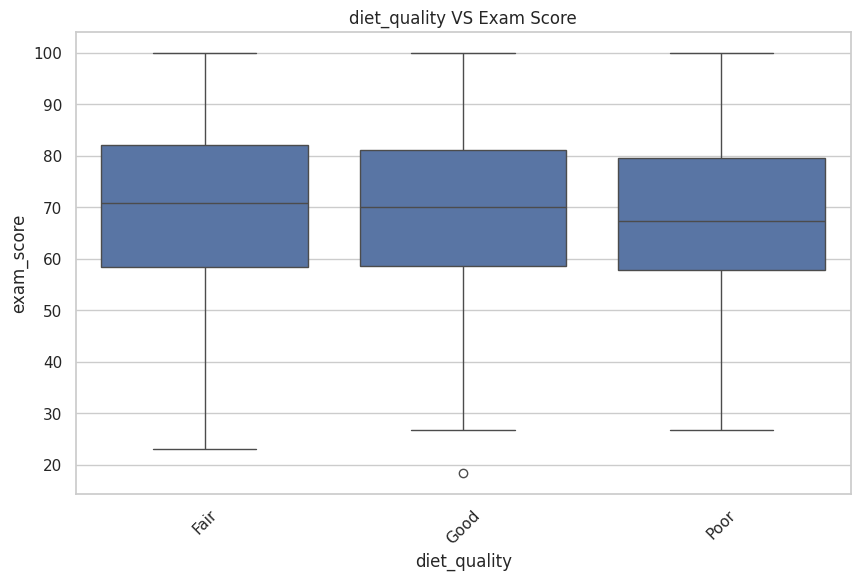

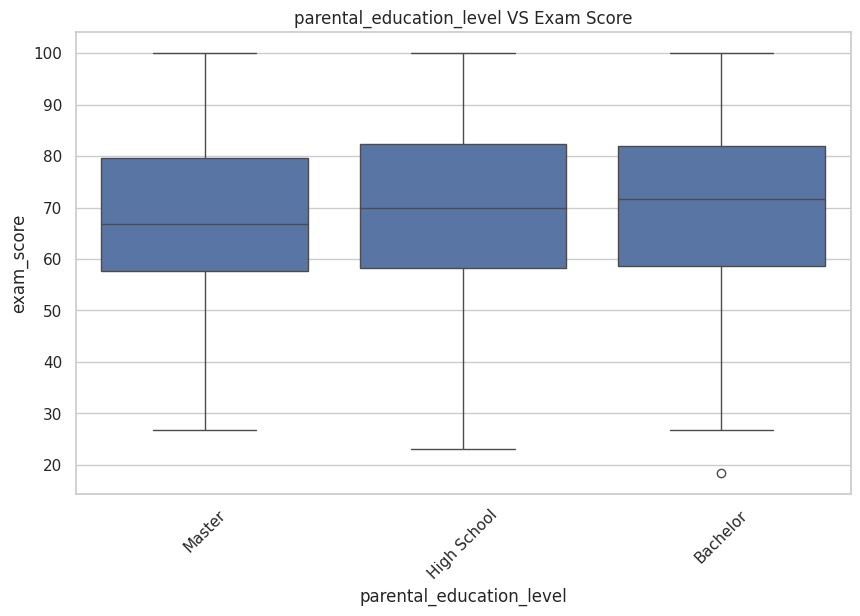

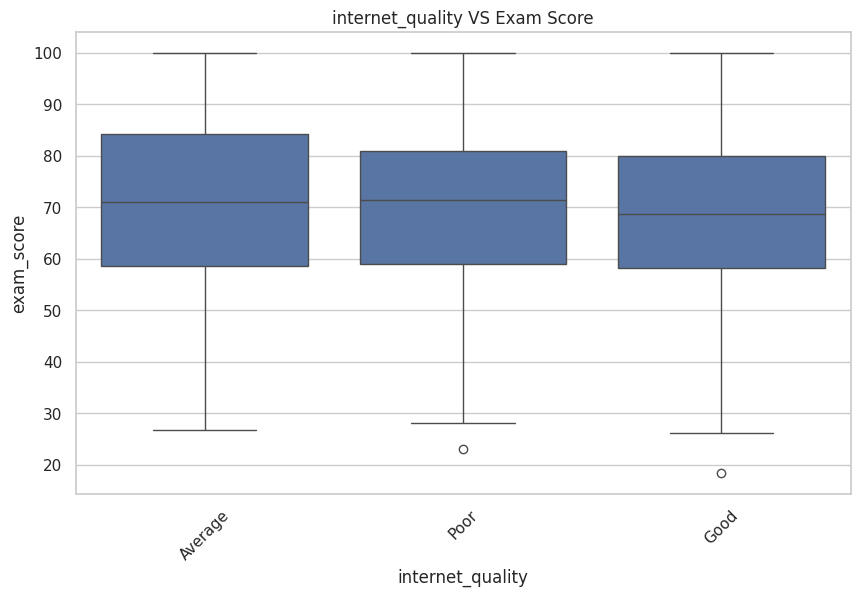

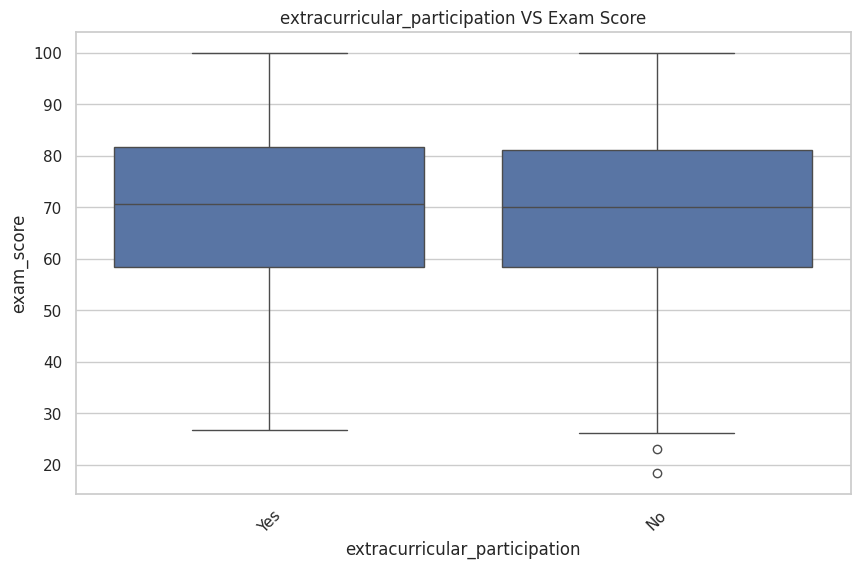

In [24]:
for col in categorical_columns:
    plt.figure(figsize = (10,6))
    sns.boxplot(data = data, x = col, y = "exam_score")
    plt.title(f"{col} VS Exam Score")
    plt.xticks(rotation = 45)
    plt.show()

In [27]:
data.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [31]:
features = ["study_hours_per_day", "social_media_hours", "attendance_percentage"
       ,"sleep_hours", "part_time_job", "mental_health_rating"]
target = "exam_score"
data_model = data[features + [target]].copy()

In [32]:
data_model

,study_hours_per_day,social_media_hours,attendance_percentage,sleep_hours,part_time_job,mental_health_rating,exam_score
0,0.0,1.2,85.0,8.0,No,8,56.2
1,6.9,2.8,97.3,4.6,No,8,100.0
2,1.4,3.1,94.8,8.0,No,1,34.3
3,1.0,3.9,71.0,9.2,No,1,26.8
4,5.0,4.4,90.9,4.9,No,1,66.4
...,...,...,...,...,...,...,...
995,2.6,0.5,77.0,7.5,No,6,76.1
996,2.9,1.0,86.0,6.8,Yes,6,65.9
997,3.0,2.6,61.9,6.5,No,9,64.4
998,5.4,4.1,100.0,7.6,Yes,1,69.7


In [35]:
LE = LabelEncoder()
data_model["part_time_job"] = LE.fit_transform(data_model["part_time_job"])
data_model

,study_hours_per_day,social_media_hours,attendance_percentage,sleep_hours,part_time_job,mental_health_rating,exam_score
0,0.0,1.2,85.0,8.0,0,8,56.2
1,6.9,2.8,97.3,4.6,0,8,100.0
2,1.4,3.1,94.8,8.0,0,1,34.3
3,1.0,3.9,71.0,9.2,0,1,26.8
4,5.0,4.4,90.9,4.9,0,1,66.4
...,...,...,...,...,...,...,...
995,2.6,0.5,77.0,7.5,0,6,76.1
996,2.9,1.0,86.0,6.8,1,6,65.9
997,3.0,2.6,61.9,6.5,0,9,64.4
998,5.4,4.1,100.0,7.6,1,1,69.7


In [66]:
x = data_model[features]
y = data_model[target]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,
                                                    random_state = 42)

In [67]:
models = {"Linear Regression": {"model": LinearRegression(), "params": {}},
          "Decision Tree": {"model": DecisionTreeRegressor(), "params": {"max_depth": [3,5,10], "min_samples_split": [2,5]}},
          "Random Forest": {"model": RandomForestRegressor(), "params": {"n_estimators": [50,100], "max_depth": [5,10]}}
}

In [68]:
best_models = []

In [69]:
for name, config in models.items():
    print(f"Training {name}")
    model = config["model"]
    params = config["params"]
    grid_search = GridSearchCV(model, params, cv = 5, scoring = "neg_mean_squared_error")
    grid_search.fit(x_train, y_train)
    y_pred = grid_search.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    best_models.append({"name": name, "best_params": grid_search.best_params_, "rmse": rmse, "r2": r2})

Training Linear Regression
Training Decision Tree
Training Random Forest


In [70]:
best_models

[{'name': 'Linear Regression',
  'best_params': {},
  'rmse': np.float64(6.548163295121436),
  'r2': 0.8420293924463522},
 {'name': 'Decision Tree',
  'best_params': {'max_depth': 5, 'min_samples_split': 5},
  'rmse': np.float64(8.096308488566047),
  'r2': 0.7585031996015608},
 {'name': 'Random Forest',
  'best_params': {'max_depth': 10, 'n_estimators': 100},
  'rmse': np.float64(6.5715410972285335),
  'r2': 0.8408994273881651}]

In [72]:
result_data = pd.DataFrame(best_models)
result_data = result_data.sort_values(by = "rmse")
result_data

,name,best_params,rmse,r2
0,Linear Regression,{},6.548163,0.842029
2,Random Forest,"{'max_depth': 10, 'n_estimators': 100}",6.571541,0.840899
1,Decision Tree,"{'max_depth': 5, 'min_samples_split': 5}",8.096308,0.758503


In [74]:
import joblib
best_row = result_data.sort_values(by = "rmse").iloc[0]
best_row

,0
name,Linear Regression
best_params,{}
rmse,6.548163
r2,0.842029


In [75]:
best_model_name = best_row["name"]
best_model_name

'Linear Regression'

In [76]:
best_model_config = models[best_model_name]
best_model_config

{'model': LinearRegression(), 'params': {}}

In [79]:
final_model = best_model_config["model"]
final_model.fit(x, y)

LinearRegression()

In [81]:
joblib.dump(final_model, "best_model.pkl")

['best_model.pkl']

In [82]:
joblib.load("best_model.pkl").predict(x_test)

array([ 56.80622675,  49.09901064,  65.99262784,  71.6868237 ,
        85.2133878 ,  63.44244599,  75.29930525,  92.68220353,
        68.09906081,  64.86245383,  56.51364859,  79.31304619,
        57.80242968,  54.03168251,  79.01195526,  77.51870544,
        48.89130237,  91.86584279,  81.27517526,  69.52763758,
        77.86558338,  96.46665786,  54.02547433,  70.71126689,
        81.90978746,  61.21559745, 106.64577313,  73.66506266,
        58.85623716,  97.95353914,  56.99946869,  84.5856608 ,
        60.5607969 ,  65.69276888,  61.57302636,  69.07452455,
        92.14702884,  52.55079128,  55.89841031,  71.75322129,
        62.08557167,  82.20828106,  65.61827928,  67.01532598,
        81.55965425,  65.55922063,  51.20303356, 104.44021012,
        79.74667706,  78.89973772,  63.47613976,  42.55942157,
        62.47412936,  74.63158735,  72.06330778, 102.72508849,
        72.73579014,  61.40527379,  79.56903571,  50.11632309,
        81.17258305,  66.50217785,  58.80362197,  75.12

In [84]:
%%writefile app.py

import streamlit as st
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")

st.set_page_config(page_title = "Student Exam Score Prediction", page_icon = "📊")

model = joblib.load("best_model.pkl")

st.title("Student Exam Score Prediction Based on Habits and Lifestyle Factors")
study_hours = st.number_input("Study Hours Per Day", min_value = 0.0, max_value = 12.0)
attendance = st.number_input("Attendance Percentage", min_value = 0.0, max_value = 100.0)
mental_health = st.number_input("Mental Health Rating", min_value = 0.0, max_value = 10.0)
sleep_hours = st.number_input("Sleep Hours", min_value = 0.0, max_value = 12.0)
social_media_hours = st.number_input("Social Media Hours", min_value = 0.0, max_value = 24.0)
part_time_job = st.selectbox("Part Time Job", ["Yes", "No"])
part_time_job_encoded = 1 if part_time_job == "Yes" else 0

if st.button("Predict Exam Score"):
    input_data = np.array([[study_hours, attendance, mental_health, sleep_hours, social_media_hours, part_time_job_encoded]])
    prediction = model.predict(input_data)
    prediction = max(0, min(100, prediction))
    st.success(f"Predicted Exam Score: {prediction:.2f}")

Writing app.py


In [85]:
!pip install -q streamlit
!streamlit run app.py &>/content/logs.txt &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 82.9 MB/s eta 0:00:00


In [93]:
!cat /content/logs.txt



2026-08-23 15:29:35.824 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.169.192:8501

  Stopping...
